# Fake News Detection Using Machine Learning
**Dataset:** ISOT Fake News Dataset (True.csv + Fake.csv)  
**Deployment Target:** Flask API (CPU-optimised)

---
## Group Details
| Name | CPM | MC |
| -- | -- | -- |
| Minoli Perera | 24375 | 108853 |
| Sandagomi Kodikara | 24377 | 108852 |
| Savindi Dissanayake | 24381 | 108798 |

---
## Table of Contents
1. Install & Import Libraries
2. Load Data & Add Labels
3. Exploratory Data Analysis (EDA)
4. Text Preprocessing
5. Train / Validation / Test Split (80/10/10)
6. TF-IDF Feature Extraction
7. Model Training
8. Evaluation, Confusion Matrices & ROC Curves
9. Cross-Validation
10. Ablation Study
11. Export Best Model for Flask

---

## Step 1: Install & Import Libraries

In [1]:
# Install required packages (run once) - if you're running on google colab
# ! pip install lightgbm xgboost wordcloud nltk scikit-learn pandas numpy matplotlib seaborn joblib kagglehub tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, string, time, joblib, json, os, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# Models
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB
from sklearn.ensemble        import RandomForestClassifier
from sklearn.calibration     import CalibratedClassifierCV
import xgboost as xgb

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

# Word cloud
from wordcloud import WordCloud

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#e74c3c', '#2ecc71']   # red = Fake, green = Real

# Model tracking
import mlflow
from mlflow import sklearn

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


---
## Step 2: Load Data & Add Labels

In [3]:
# Set the experiment name
mlflow.set_experiment('Fake News Detection')

import kagglehub

# Download dataset from Kaggle
path = kagglehub.dataset_download('clmentbisaillon/fake-and-real-news-dataset', output_dir='data/')


print('Loading datasets...')
true_df = pd.read_csv(f'{path}/True.csv')
fake_df = pd.read_csv(f'{path}/Fake.csv')

true_df['label'] = 1   # 1 = Real
fake_df['label'] = 0   # 0 = Fake

news_df = pd.concat([true_df, fake_df], axis=0)
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)  

print(f'Total rows    : {len(news_df):,}')
print(f'Columns       : {list(news_df.columns)}')
print(f'\nClass distribution (0=Fake, 1=Real):')
print(news_df['label'].value_counts())
news_df.head(3)

2026/05/06 15:20:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/06 15:20:03 INFO mlflow.store.db.utils: Updating database tables
2026/05/06 15:20:05 INFO mlflow.tracking.fluent: Experiment with name 'Fake News Detection' does not exist. Creating a new experiment.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41.0M/41.0M [02:03<00:00, 348kB/s]

Extracting files...


Loading datasets...
Total rows    : 44,898
Columns       : ['title', 'text', 'subject', 'date', 'label']

Class distribution (0=Fake, 1=Real):
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0


---
## Step 3: Exploratory Data Analysis (EDA)
### 3a. Class Distribution

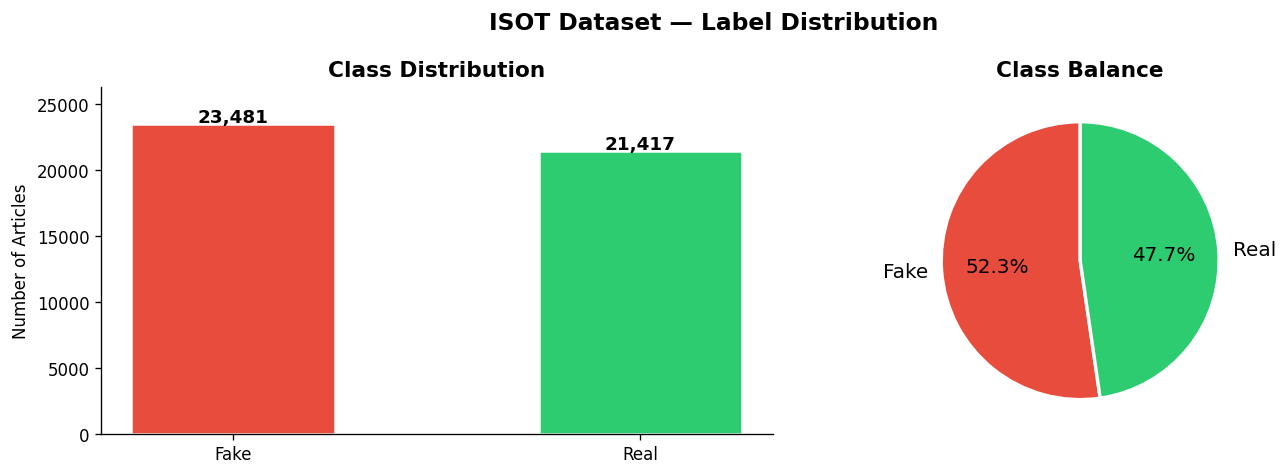

Mild imbalance (~52% Fake / ~48% Real) — manageable with stratified splits.


In [4]:
counts = news_df['label'].value_counts().sort_index()  # [Fake, Real]
labels = ['Fake', 'Real']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
axes[0].set_ylim(0, max(counts.values) * 1.12)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('ISOT Dataset — Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Mild imbalance (~52% Fake / ~48% Real) — manageable with stratified splits.')

### 3b. Article Length Distribution

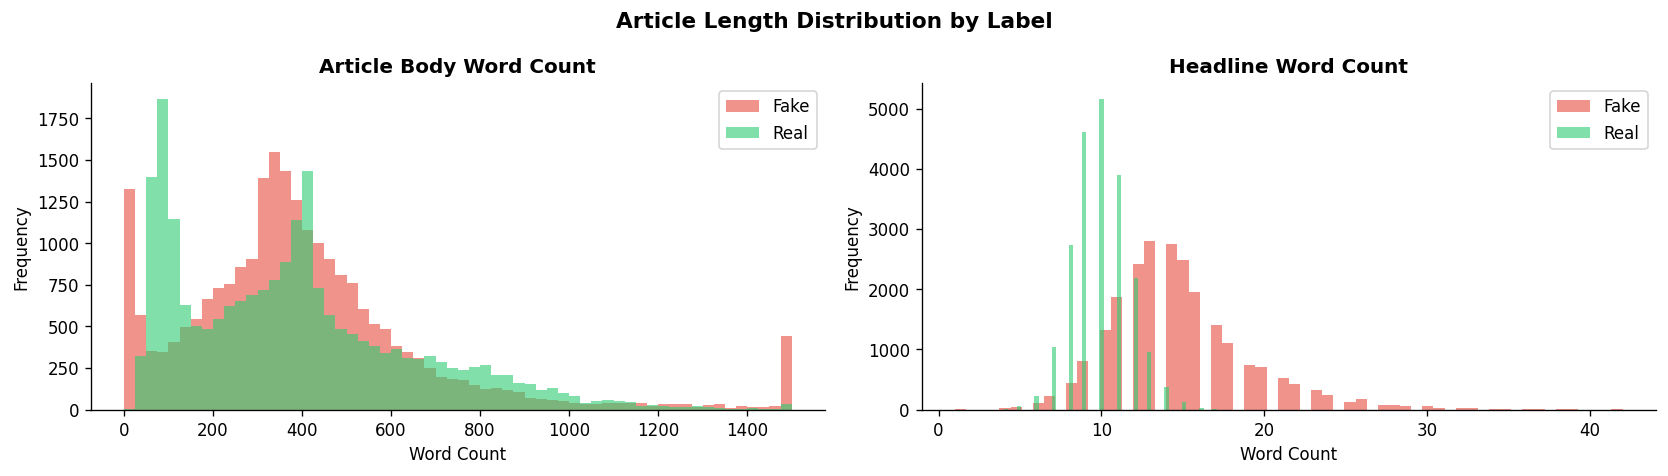


Body length statistics by label:
         count   mean    std  min    25%    50%    75%     max
label                                                         
Fake   23481.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0
Real   21417.0  385.6  274.0  0.0  148.0  359.0  525.0  5172.0


In [5]:
news_df['text_len']  = news_df['text'].str.split().str.len()
news_df['title_len'] = news_df['title'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, (col, title) in enumerate([('text_len',  'Article Body Word Count'),
                                    ('title_len', 'Headline Word Count')]):
    for label_val, color, name in zip([0, 1], PALETTE, ['Fake', 'Real']):
        axes[i].hist(
            news_df[news_df['label'] == label_val][col].clip(upper=1500),
            bins=60, alpha=0.6, color=color, label=name, edgecolor='none')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Word Count')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Article Length Distribution by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nBody length statistics by label:')
print(news_df.groupby('label')['text_len'].describe()
      .round(1).rename(index={0: 'Fake', 1: 'Real'}))

### 3c. Subject Category Distribution

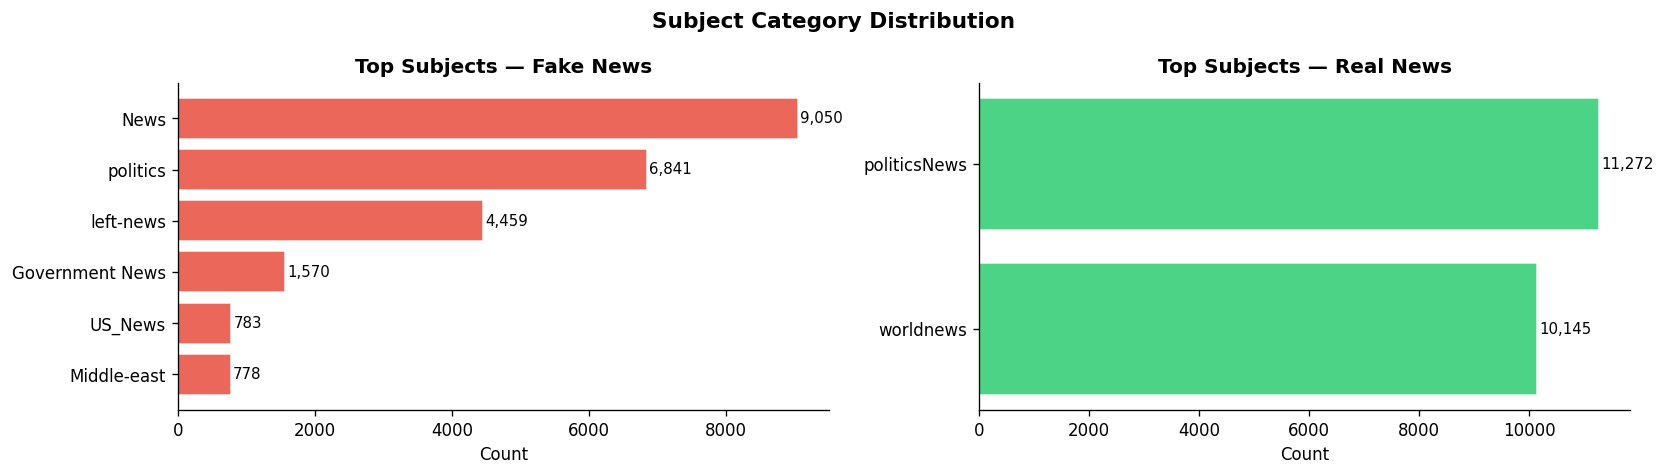

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label_val, title, color) in zip(
        axes, [(0, 'Fake News', '#e74c3c'), (1, 'Real News', '#2ecc71')]):
    cnts = news_df[news_df['label'] == label_val]['subject'].value_counts().head(8)
    ax.barh(cnts.index[::-1], cnts.values[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top Subjects — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(cnts.values[::-1]):
        ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Subject Category Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3d. Word Clouds

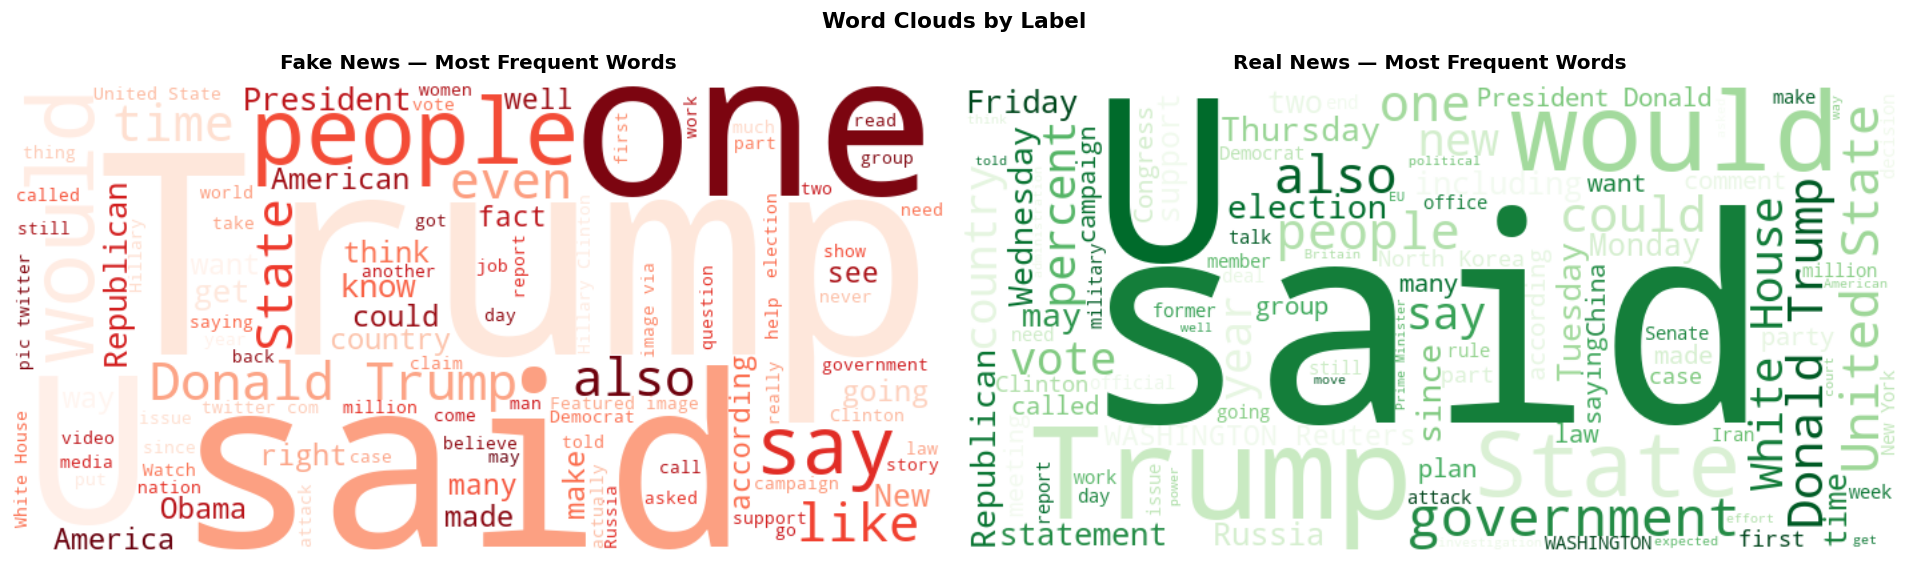

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sw = set(stopwords.words('english'))

for ax, (label_val, title, cmap) in zip(axes, [
        (0, 'Fake News — Most Frequent Words', 'Reds'),
        (1, 'Real News — Most Frequent Words', 'Greens')]):
    sample_size = min(3000, (news_df['label'] == label_val).sum())
    text = ' '.join(
        news_df[news_df['label'] == label_val]['text']
        .dropna().sample(sample_size, random_state=42)
    )
    wc = WordCloud(width=700, height=350, background_color='white',
                   max_words=100, colormap=cmap, stopwords=sw).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Word Clouds by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: Text Preprocessing

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    text = str(text).lower()

    # ── Data-leakage fix ───────────────────────────────────────────────────────
    # Real articles often start with "CITY (Reuters) -"; remove this source tag
    # so the model learns content patterns, not publisher identity.
    text = re.sub(r'\(reuters\)\s*-\s*', '', text)
    text = re.sub(r'\breuters\b', '', text)
    # ──────────────────────────────────────────────────────────────────────────

    text = re.sub(r'https?://\S+|www\.\S+', '', text)          # Remove URLs
    text = re.sub(r'<.*?>', '', text)                            # Remove HTML
    text = re.sub(r"won't", 'will not', text)                   # Expand contractions
    text = re.sub(r"can't", 'cannot', text)
    text = re.sub(r"n't",   ' not', text)
    text = re.sub(r"'re",   ' are', text)
    text = re.sub(r"'ve",   ' have', text)
    text = re.sub(r"'ll",   ' will', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                    # Normalise whitespace

    # Tokenise → remove stopwords → lemmatize  ← NEW
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

# Combine title + text for richer signal, then clean
print('Combining title + text and applying preprocessing...')
print('(This takes ~1-2 minutes on Colab)')
t0 = time.time()

news_df['full_text']  = news_df['title'] + ' ' + news_df['text']
news_df['clean_text'] = news_df['full_text'].apply(clean_text)

print(f'Done in {time.time()-t0:.1f}s ✓')
print(f'\nSample before: {news_df["full_text"].iloc[0][:120]}')
print(f'Sample after : {news_df["clean_text"].iloc[0][:120]}')

Combining title + text and applying preprocessing...
(This takes ~1-2 minutes on Colab)
Done in 57.3s ✓

Sample before:  BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and
Sample after : breaking gop chairman grassley enough demand trump testimony donald trump white house chaos trying cover russia problem 


---
## Step 5: Train / Validation / Test Split (80 / 10 / 10)

In [9]:
X = news_df['clean_text']
y = news_df['label']

# Step 1: split off 20% as temp set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# Step 2: split temp equally into val and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {len(X_train):,} samples  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val):,}  samples  ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):,}  samples  ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nClass balance in train — Fake: {sum(y_train==0):,}  Real: {sum(y_train==1):,}')

Train : 35,918 samples  (80.0%)
Val   : 4,490  samples  (10.0%)
Test  : 4,490  samples  (10.0%)

Class balance in train — Fake: 18,785  Real: 17,133


---
## Step 6: TF-IDF Feature Extraction

Fitting TF-IDF on training data only...
Done in 39.5s ✓
Vocabulary size : 50,000
Train matrix    : (35918, 50000)


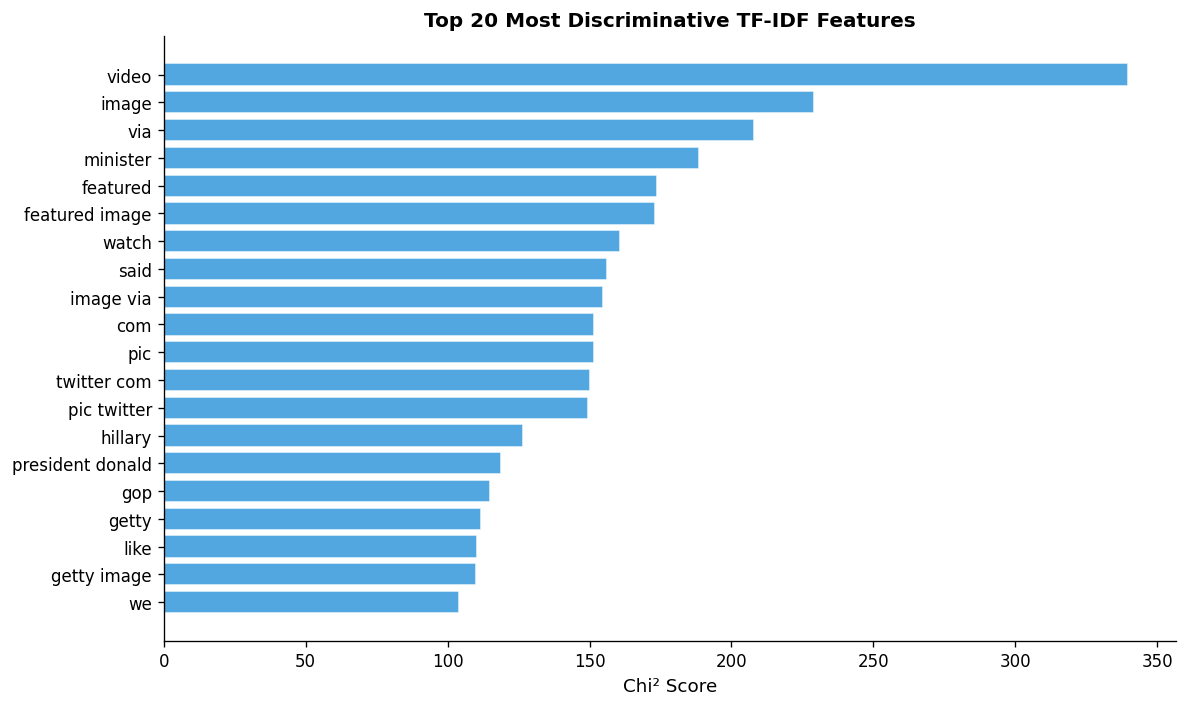

In [10]:
# Fit ONLY on training data — never on val/test
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),     
    max_features=50_000,    
    sublinear_tf=True,      
    min_df=3,               
    max_df=0.90,            
    strip_accents='unicode' 
)

print('Fitting TF-IDF on training data only...')
t0 = time.time()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)   # fit + transform
X_val_tfidf   = tfidf_vectorizer.transform(X_val)         # transform only
X_test_tfidf  = tfidf_vectorizer.transform(X_test)        # transform only

print(f'Done in {time.time()-t0:.1f}s ✓')
print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'Train matrix    : {X_train_tfidf.shape}')

# Top discriminative features
chi2_scores, _ = chi2(X_train_tfidf, y_train)
feat_names     = tfidf_vectorizer.get_feature_names_out()
top_idx        = np.argsort(chi2_scores)[::-1][:20]
top_feats      = [(feat_names[i], chi2_scores[i]) for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
names, scores = zip(*top_feats[::-1])
ax.barh(names, scores, color='#3498db', alpha=0.85, edgecolor='white')
ax.set_xlabel('Chi² Score', fontsize=11)
ax.set_title('Top 20 Most Discriminative TF-IDF Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7: Model Training

In [11]:
# Shared evaluation helper
def evaluate(model, X_vec, y_true, flavor="sklearn"):
    # 1. Check if the model is a TensorFlow/Keras model
    if flavor == 'tensorflow':
        y_prob = model.predict(X_vec, verbose=0).flatten() # Keras predict() returns 2D probabilities (e.g., [[0.9], [0.1]])
        y_pred = (y_prob > 0.5).astype(int) # Convert probabilities to discrete 0 or 1 classes for accuracy/f1
    
    # 2. Otherwise, treat it as a standard Scikit-Learn model
    else:
        y_pred = model.predict(X_vec)
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_vec)[:, 1]
        
        else:
            y_prob = model.decision_function(X_vec)
            
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall'   : recall_score(y_true, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro'),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

In [12]:
# Tracking models
def train_and_log_models(model_class, model_name, X_train, y_train, X_val, y_val, flavor = 'sklearn', tokenizer = None, **params):
    with mlflow.start_run(run_name = model_name):
        # 1. Initialize the model with the optional parameters
        model = model_class(**params)

        # 2. Log hyperparameters automatically
        mlflow.log_params(params)

        # 3. Train the model
        t0 = time.time()
        if flavor == 'tensorflow':
            model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = 3, batch_size = 64, verbose=1)

        else:
            model.fit(X_train, y_train)

        train_time = time.time() - t0

        # 4. Evaluate and log metrics
        results = evaluate(model, X_val, y_val, flavor = flavor)

        mlflow.log_metrics({
            "accuracy": results['Accuracy'],
            "precision": results['Precision'],
            "recall": results['Recall'],
            "f1_macro": results['F1 (macro)'],
            "roc_auc": results['ROC-AUC'],
            "train_time": train_time
        })

        # 5. Log a plot as artifact
        fig, ax = plt.subplots(figsize = (8, 5))
        cm = confusion_matrix(y_val, results['y_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)  
        ax.set_title(f'Actual vs Predicted - {model_name}')
        plt.tight_layout()
        plt.savefig('actual-vs-predicted.png', dpi = 120)
        plt.close()

        mlflow.log_artifact('actual-vs-predicted.png')

        # 6. Log the model
        if flavor == 'tensorflow':
            mlflow.tensorflow.log_model(
                model,
                name = 'model',
                registered_model_name=f'FakeNewsClassification_{model_name}'
            )

            if tokenizer:
                # Save tokenizer explicitly for DL models
                with open('tokenizer.json', 'w') as f:
                    f.write(tokenizer.to_json())
                mlflow.log_artifact('tokenizer.json')
        
        else:
            mlflow.sklearn.log_model(
                model,
                name = 'model',
                registered_model_name = f'FakeNewsClassification_{model_name}'
            )

        # Fixed f-string quote issue inside dictionary access
        print(f'\n[{model_name}] Accuracy: {results['Accuracy']:.4f} | Precision: {results['Precision']:.4f} | Recall: {results['Recall']:.4f} | F1_Macro: {results['F1 (macro)']:.4f} | ROC-AUC: {results['ROC-AUC']:.4f}')

        return model, results

### 7a. Logistic Regression

In [13]:
val_results = {}

In [14]:
print('Training Logistic Regression...')
log_model, val_results['LogisticRegression'] = train_and_log_models(
    LogisticRegression,
    'LogisticRegression',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    max_iter=1000, 
    random_state=42, 
    n_jobs=-1
)

Training Logistic Regression...


2026/05/06 15:24:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 15:26:06 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\mnnet\AppData\Local\Temp\tmp8lipe6q8\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 



[LogisticRegression] Accuracy: 0.9886 | Precision: 0.9884 | Recall: 0.9889 | F1_Macro: 0.9886 | ROC-AUC: 0.9990


Successfully registered model 'FakeNewsClassification_LogisticRegression'.
Created version '1' of model 'FakeNewsClassification_LogisticRegression'.


### 7b. Naive Bayes

In [15]:
print('Training Naive Bayes...')
nb_model, val_results['NaiveBayes'] = train_and_log_models(
    MultinomialNB,
    'NaiveBayes',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    alpha=0.1
)

Training Naive Bayes...


2026/05/06 15:26:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 15:28:07 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\mnnet\AppData\Local\Temp\tmp6e200gg1\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 



[NaiveBayes] Accuracy: 0.9624 | Precision: 0.9623 | Recall: 0.9623 | F1_Macro: 0.9623 | ROC-AUC: 0.9919


Successfully registered model 'FakeNewsClassification_NaiveBayes'.
Created version '1' of model 'FakeNewsClassification_NaiveBayes'.


### 7c. Linear SVM

In [16]:
print('Training Linear SVM...')

# Wrap with CalibratedClassifierCV so we get predict_proba for ROC curve
svm_base  = LinearSVC(random_state=42, dual=False, max_iter=2000)
svm_model, val_results['LinearSVM'] = train_and_log_models(
    CalibratedClassifierCV,
    'LinearSVM',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    estimator = svm_base,
    cv=3
)


Training Linear SVM...


2026/05/06 15:28:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 15:30:11 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\mnnet\AppData\Local\Temp\tmprzfjks1t\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 



[LinearSVM] Accuracy: 0.9955 | Precision: 0.9955 | Recall: 0.9955 | F1_Macro: 0.9955 | ROC-AUC: 0.9998


Successfully registered model 'FakeNewsClassification_LinearSVM'.
Created version '1' of model 'FakeNewsClassification_LinearSVM'.


### 7d. Random Forest

In [17]:
print('Training Random Forest...')
rf_model, val_results['RandomForestClassifier'] = train_and_log_models(
    RandomForestClassifier,
    'RandomForestClassifier',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)

Training Random Forest...


2026/05/06 15:30:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 15:32:23 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\mnnet\AppData\Local\Temp\tmpo6uinpsf\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 



[RandomForestClassifier] Accuracy: 0.9900 | Precision: 0.9898 | Recall: 0.9901 | F1_Macro: 0.9900 | ROC-AUC: 0.9993


Successfully registered model 'FakeNewsClassification_RandomForestClassifier'.
Created version '1' of model 'FakeNewsClassification_RandomForestClassifier'.


### 7e. XGBoost

In [18]:
print('Training XGBoost...')
xgb_model, val_results['XGBoost'] = train_and_log_models(
    xgb.XGBClassifier,
    'XGBoost',
    X_train_tfidf,
    y_train,
    X_val_tfidf,
    y_val,
    eval_metric='logloss', 
    random_state=42, 
    n_jobs=-1
)

Training XGBoost...


2026/05/06 15:33:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 15:35:59 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\mnnet\AppData\Local\Temp\tmpfutehzar\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 



[XGBoost] Accuracy: 0.9931 | Precision: 0.9930 | Recall: 0.9931 | F1_Macro: 0.9931 | ROC-AUC: 0.9997


Successfully registered model 'FakeNewsClassification_XGBoost'.
Created version '1' of model 'FakeNewsClassification_XGBoost'.


### 7f. 1D CNN (Neural Architecture)

In [19]:
print('Preparing tokenizer for 1D CNN...')
MAX_WORDS = 10000
MAX_LEN   = 500

# 1. Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)   # fit on train only

# 2. Convert text to sequences and pad them
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN)

# 3. Building 1D CNN
print('Building 1D CNN architecture...')
def build_1d_cnn(max_words = 10000, max_len = 500, filters = 64, kernel_size = 5):
    model = Sequential([
        Embedding(input_dim = max_words, output_dim=50, input_length = max_len),
        Conv1D(filters = filters, kernel_size = kernel_size, activation='relu'),
        GlobalMaxPooling1D(), 
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 4. Model tracking
dl_model, val_results['1DCNNArchitecture'] = train_and_log_models(
    build_1d_cnn,
    '1DCNNArchitecture',
    X_train_seq,
    y_train,
    X_val_seq,
    y_val,
    flavor = 'tensorflow',
    tokenizer = tokenizer,
    max_words = MAX_WORDS,
    max_len = MAX_LEN,
    filters = 64,
    kernel_size = 5
)

Preparing tokenizer for 1D CNN...
Building 1D CNN architecture...
Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9398 - loss: 0.1566 - val_accuracy: 0.9913 - val_loss: 0.0275
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.9945 - loss: 0.0211 - val_accuracy: 0.9947 - val_loss: 0.0190
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.9989 - loss: 0.0062 - val_accuracy: 0.9913 - val_loss: 0.0257


2026/05/06 15:37:31 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/06 15:39:31 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\mnnet\AppData\Local\Temp\tmp9gfdvc86\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
Successfully registered model 'FakeNewsClassification_1DCNNArchitecture'.
Created version '1' of model 'FakeNewsClassification_1DCNNArchitecture'.



[1DCNNArchitecture] Accuracy: 0.9913 | Precision: 0.9911 | Recall: 0.9916 | F1_Macro: 0.9913 | ROC-AUC: 0.9998


---
## Step 8: Evaluation, Confusion Matrices & ROC Curves

### 8a. ROC Curves for All Models

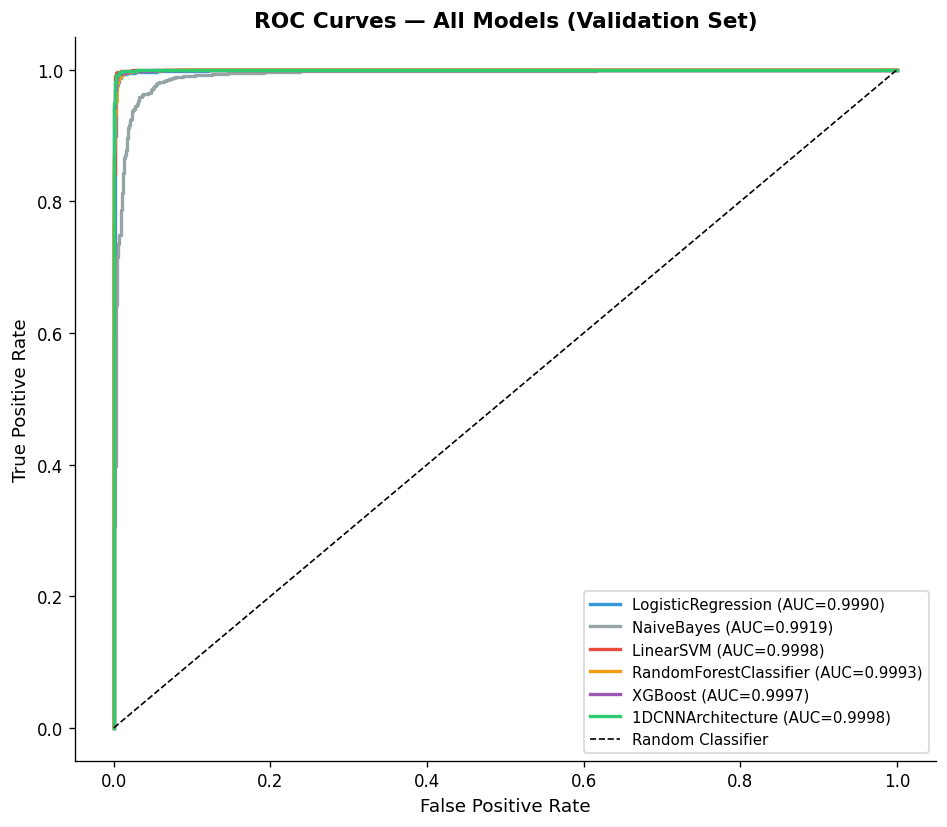

In [20]:
roc_colors = ['#3498db','#95a5a6','#e74c3c','#f39c12','#9b59b6','#2ecc71']

fig, ax = plt.subplots(figsize=(8, 7))
for (name, res), color in zip(val_results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_val, res['y_prob'])
    auc = res['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models (Validation Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## Step 9: MLflow Model Registry — Promote LinearSVM as candidate

In [21]:
client = mlflow.tracking.MlflowClient()

# 1. Find the LinearSVM run ID from the experiment
experiment = mlflow.get_experiment_by_name('Fake News Detection')
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'LinearSVM'"
)

if runs_df.empty:
    raise ValueError("LinearSVM run not found in MLflow. Ensure Step 7 completed successfully.")

svm_run_id = runs_df.iloc[0]['run_id']
print(f"Found LinearSVM run: {svm_run_id}")

# 2. Register the model (may already exist if Step 7 used registered_model_name)
MODEL_REGISTRY_NAME = 'FakeNewsClassification_LinearSVM'

try:
    client.get_registered_model(MODEL_REGISTRY_NAME)
    print(f"Model '{MODEL_REGISTRY_NAME}' already registered.")
except Exception:
    mlflow.register_model(f'runs:/{svm_run_id}/model', MODEL_REGISTRY_NAME)
    print(f"Model '{MODEL_REGISTRY_NAME}' registered.")

# Get latest version number
versions = client.get_latest_versions(MODEL_REGISTRY_NAME)
latest_version = versions[0].version
print(f"Latest version: {latest_version}")

# 3. Transition to Staging
client.transition_model_version_stage(
    name    = MODEL_REGISTRY_NAME,
    version = latest_version,
    stage   = 'Staging',
    archive_existing_versions=True
)
print(f"Version {latest_version} transitioned to → Staging")

# 4. Add description and tags
client.update_registered_model(
    name        = MODEL_REGISTRY_NAME,
    description = (
        'Best performing classical model on ISOT Fake News dataset. Selected after comparison of LR, NB, SVM, RF, XGBoost, and 1D-CNN on validation F1-macro. CPU-efficient for Flask deployment.'
    )
)

client.set_model_version_tag(MODEL_REGISTRY_NAME, latest_version, 'selection_reason',
    'Highest val F1-macro among classical models. Fast inference on CPU.')
client.set_model_version_tag(MODEL_REGISTRY_NAME, latest_version, 'status',
    'pre_tuning_baseline')
client.set_model_version_tag(MODEL_REGISTRY_NAME, latest_version, 'feature_config',
    'Title+Text TF-IDF (1,2)-gram 50k features')

# 5. Snapshot baseline metrics before tuning
baseline = val_results['LinearSVM']

with mlflow.start_run(run_name='LinearSVM_Baseline_Snapshot'):
    mlflow.set_tag('stage', 'baseline_before_tuning')
    mlflow.set_tag('model', 'LinearSVM')
    mlflow.log_metrics({
        'baseline_val_accuracy'  : round(baseline['Accuracy'],    4),
        'baseline_val_f1_macro'  : round(baseline['F1 (macro)'],  4),
        'baseline_val_roc_auc'   : round(baseline['ROC-AUC'],     4),
        'baseline_val_precision' : round(baseline['Precision'],   4),
        'baseline_val_recall'    : round(baseline['Recall'],      4),
    })

print(f"\n=== Baseline (pre-tuning) Validation Metrics ===")
print(f"  Accuracy  : {baseline['Accuracy']:.4f}")
print(f"  F1 (macro): {baseline['F1 (macro)']:.4f}")
print(f"  ROC-AUC   : {baseline['ROC-AUC']:.4f}")
print(f"\nMLflow Registry status: '{MODEL_REGISTRY_NAME}' v{latest_version} → Staging ✓")

Found LinearSVM run: 23f3971f09cb4a9ea8c01c212eea62bd
Model 'FakeNewsClassification_LinearSVM' already registered.
Latest version: 1
Version 1 transitioned to → Staging

=== Baseline (pre-tuning) Validation Metrics ===
  Accuracy  : 0.9955
  F1 (macro): 0.9955
  ROC-AUC   : 0.9998

MLflow Registry status: 'FakeNewsClassification_LinearSVM' v1 → Staging ✓


---
## Step 10: Hyperparameter Tuning — Linear SVM.

Train+Val size: 40,408 samples

Running RandomizedSearchCV (5-fold, scoring=f1_macro)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ..................................estimator__C=0.01; total time=   2.1s
[CV] END ..................................estimator__C=0.01; total time=   1.2s
[CV] END ..................................estimator__C=0.01; total time=   1.2s
[CV] END ..................................estimator__C=0.01; total time=   1.2s
[CV] END ..................................estimator__C=0.01; total time=   1.2s
[CV] END ..................................estimator__C=0.05; total time=   1.5s
[CV] END ..................................estimator__C=0.05; total time=   1.5s
[CV] END ..................................estimator__C=0.05; total time=   1.4s
[CV] END ..................................estimator__C=0.05; total time=   1.5s
[CV] END ..................................estimator__C=0.05; total time=   1.5s
[CV] END ................................

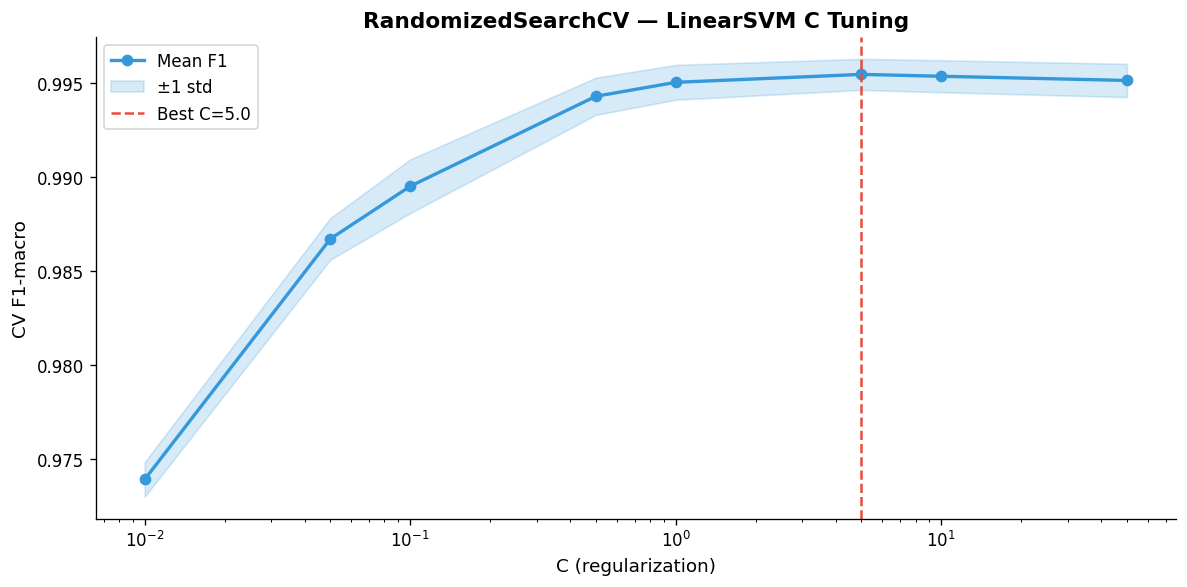

2026/05/06 15:43:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 15:45:53 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\mnnet\AppData\Local\Temp\tmpfhnea4vz\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
Registered model 'FakeNewsClassification_LinearSVM' already exists. Creating a new version of this model...
Created version '2' of model 'FakeNewsClassification_LinearSVM'.



Tuned model registered as 'FakeNewsClassification_LinearSVM' v1 ✓


In [23]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.sparse as sp

# 1. Combine train + val (test remains untouched)
X_tv = sp.vstack([X_train_tfidf, X_val_tfidf])
y_tv = pd.concat([y_train, y_val]).reset_index(drop=True)
print(f"Train+Val size: {X_tv.shape[0]:,} samples")

# 2. Define base pipeline
svm_base    = LinearSVC(loss='squared_hinge', dual=False, max_iter=3000, random_state=42)
svm_calib   = CalibratedClassifierCV(svm_base, cv=3)

param_dist = {
    'estimator__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
}

search = RandomizedSearchCV(
    estimator  = svm_calib,
    param_distributions = param_dist,
    n_iter     = 8,          
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = 1,
    verbose    = 2,
    random_state = 42,
    refit      = True,
)

print("\nRunning RandomizedSearchCV (5-fold, scoring=f1_macro)...")
t0 = time.time()
search.fit(X_tv, y_tv)
tuning_time = time.time() - t0
print(f"Done in {tuning_time:.1f}s ✓")

print(f"\nBest params : {search.best_params_}")
print(f"Best CV F1  : {search.best_score_:.4f}")
print(f"Baseline F1 : {baseline['F1 (macro)']:.4f}  (Δ {search.best_score_ - baseline['F1 (macro)']:+.4f})")

# 3. Store the tuned model
tuned_svm = search.best_estimator_

# 4. Plot CV results across C values
cv_results_df = pd.DataFrame(search.cv_results_)
cv_results_df = cv_results_df.sort_values('param_estimator__C')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cv_results_df['param_estimator__C'].astype(float),
        cv_results_df['mean_test_score'], marker='o', color='#3498db', lw=2, label='Mean F1')
ax.fill_between(
    cv_results_df['param_estimator__C'].astype(float),
    cv_results_df['mean_test_score'] - cv_results_df['std_test_score'],
    cv_results_df['mean_test_score'] + cv_results_df['std_test_score'],
    alpha=0.2, color='#3498db', label='±1 std'
)
ax.axvline(search.best_params_['estimator__C'], color='#e74c3c',
           linestyle='--', lw=1.5, label=f"Best C={search.best_params_['estimator__C']}")
ax.set_xscale('log')
ax.set_xlabel('C (regularization)', fontsize=11)
ax.set_ylabel('CV F1-macro', fontsize=11)
ax.set_title('RandomizedSearchCV — LinearSVM C Tuning', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('svm_tuning_curve.png', dpi=120)
plt.show()

# 5. Log tuning run to MLflow
cv_results_df.to_csv('svm_cv_results.csv', index=False)

with mlflow.start_run(run_name='LinearSVM_HyperparamTuning'):
    mlflow.set_tag('stage', 'hyperparameter_tuning')
    mlflow.set_tag('model', 'LinearSVM')
    mlflow.log_params(search.best_params_)
    mlflow.log_metrics({
        'best_cv_f1_macro' : round(search.best_score_, 4),
        'baseline_f1_macro': round(baseline['F1 (macro)'], 4),
        'delta_f1'         : round(search.best_score_ - baseline['F1 (macro)'], 4),
        'tuning_time_s'    : round(tuning_time, 1),
    })
    mlflow.log_artifact('svm_tuning_curve.png')
    mlflow.log_artifact('svm_cv_results.csv')
    mlflow.sklearn.log_model(
        tuned_svm,
        name = 'model',
        registered_model_name = MODEL_REGISTRY_NAME
    )

# 6. Update registry — tag new version as tuned
tuned_versions = client.get_latest_versions(MODEL_REGISTRY_NAME)
tuned_version  = tuned_versions[0].version

client.set_model_version_tag(MODEL_REGISTRY_NAME, tuned_version, 'status', 'post_tuning')
client.set_model_version_tag(MODEL_REGISTRY_NAME, tuned_version, 'best_C',
                              str(search.best_params_['estimator__C']))
print(f"\nTuned model registered as '{MODEL_REGISTRY_NAME}' v{tuned_version} ✓")

---
## Step 11: Ablation Study — Feature Combination
Using LinearSVM with DEFAULT params (not tuned) to isolate feature contribution.

We test the **best classical model (Linear SVM)** under 4 feature configurations:
1. Title only
2. Text body only
3. Title + Text *(current setup)*
4. Title + Text + Subject (one-hot encoded)

Running ablation study (LinearSVM default params)...

  Config 1: Title only                   F1=0.9670  AUC=0.9950
  Config 2: Text body only               F1=0.9955  AUC=0.9998
  Config 3: Title + Text (baseline)      F1=0.9955  AUC=0.9998
  Config 4: Title + Text + Subject ⚠     F1=1.0000  AUC=1.0000

Ablation winner: Config 4: Title + Text + Subject ⚠
Winner F1      : 1.0000


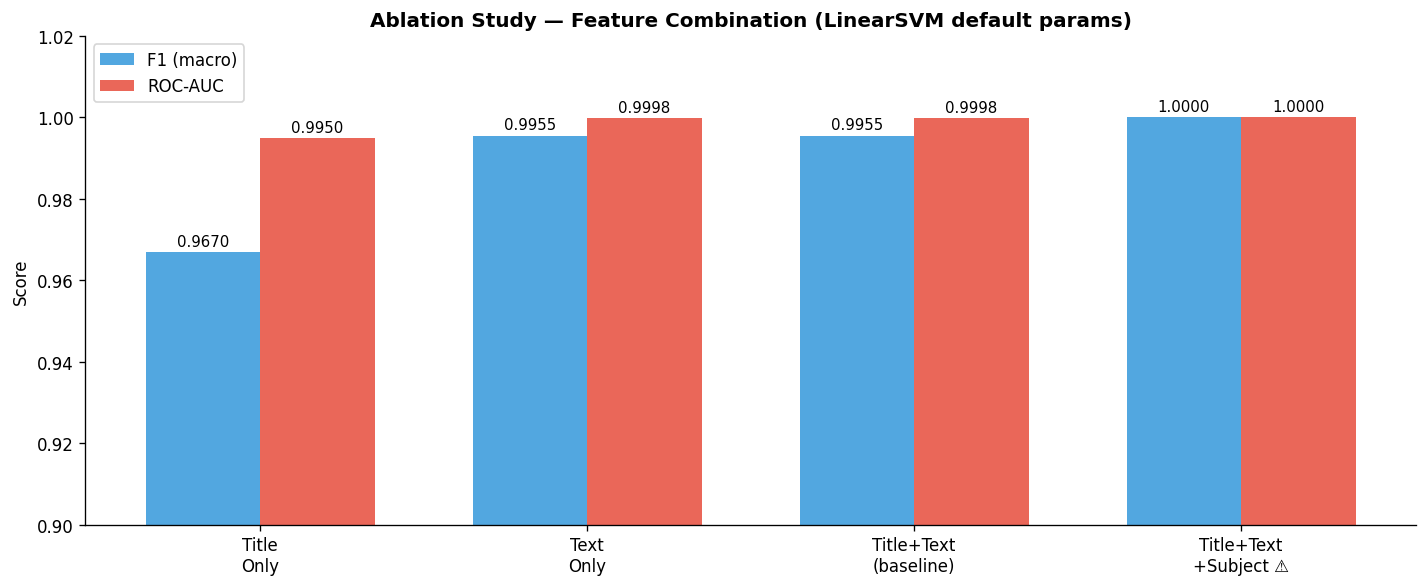

In [24]:
from scipy.sparse import hstack
from sklearn.preprocessing import OneHotEncoder

svm_default = CalibratedClassifierCV(
    LinearSVC(loss='squared_hinge', dual=False, max_iter=3000, random_state=42), cv=3
)

ablation_results = {}

def run_ablation_config(name, X_tr, X_v):
    clf = CalibratedClassifierCV(
        LinearSVC(loss='squared_hinge', dual=False, max_iter=3000, random_state=42), cv=3
    )
    clf.fit(X_tr, y_train)
    res = evaluate(clf, X_v, y_val)
    ablation_results[name] = res
    print(f"  {name:<38} F1={res['F1 (macro)']:.4f}  AUC={res['ROC-AUC']:.4f}")

print("Running ablation study (LinearSVM default params)...\n")

# Config 1: Title only
v_title = TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                           sublinear_tf=True, min_df=3, max_df=0.90)
run_ablation_config(
    'Config 1: Title only',
    v_title.fit_transform(news_df.loc[X_train.index, 'title'].fillna('')),
    v_title.transform(news_df.loc[X_val.index, 'title'].fillna(''))
)

# Config 2: Text body only
v_body = TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                          sublinear_tf=True, min_df=3, max_df=0.90)
run_ablation_config(
    'Config 2: Text body only',
    v_body.fit_transform(news_df.loc[X_train.index, 'clean_text'].fillna('')),
    v_body.transform(news_df.loc[X_val.index, 'clean_text'].fillna(''))
)

# Config 3: Title + Text (current baseline — reuse existing TF-IDF matrices)
ablation_results['Config 3: Title + Text (baseline)'] = val_results['LinearSVM']
print(f"  {'Config 3: Title + Text (baseline)':<38} "
      f"F1={val_results['LinearSVM']['F1 (macro)']:.4f}  "
      f"AUC={val_results['LinearSVM']['ROC-AUC']:.4f}")

# Config 4: Title + Text + Subject (one-hot)
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
subj_train = ohe.fit_transform(news_df.loc[X_train.index, 'subject'].values.reshape(-1, 1))
subj_val   = ohe.transform(news_df.loc[X_val.index,   'subject'].values.reshape(-1, 1))
run_ablation_config(
    'Config 4: Title + Text + Subject ⚠',
    hstack([X_train_tfidf, subj_train]),
    hstack([X_val_tfidf,   subj_val])
)

# 1. Identify ablation winner (excluding Config 4 if it shows suspiciously large jump)
config3_f1 = ablation_results['Config 3: Title + Text (baseline)']['F1 (macro)']
config4_f1 = ablation_results['Config 4: Title + Text + Subject ⚠']['F1 (macro)']

if (config4_f1 - config3_f1) > 0.015:
    print(f"\n⚠ WARNING: Config 4 shows +{config4_f1 - config3_f1:.4f} jump over baseline.")
    print("  This likely indicates subject column leakage. Excluding from selection.")
    safe_configs = {k: v for k, v in ablation_results.items() if '⚠' not in k}
else:
    safe_configs = ablation_results

ablation_winner = max(safe_configs, key=lambda k: safe_configs[k]['F1 (macro)'])
print(f"\nAblation winner: {ablation_winner}")
print(f"Winner F1      : {safe_configs[ablation_winner]['F1 (macro)']:.4f}")

# 2. Plot ablation results
abl_names = list(ablation_results.keys())
abl_f1    = [ablation_results[n]['F1 (macro)'] for n in abl_names]
abl_auc   = [ablation_results[n]['ROC-AUC']    for n in abl_names]
short_names = ['Title\nOnly', 'Text\nOnly', 'Title+Text\n(baseline)', 'Title+Text\n+Subject ⚠']

x     = np.arange(len(abl_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, abl_f1,  width, label='F1 (macro)', color='#3498db', alpha=0.85)
b2 = ax.bar(x + width/2, abl_auc, width, label='ROC-AUC',    color='#e74c3c', alpha=0.85)
ax.bar_label(b1, fmt='%.4f', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=2, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylim(0.90, 1.02)
ax.set_ylabel('Score')
ax.set_title('Ablation Study — Feature Combination (LinearSVM default params)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('ablation_results.png', dpi=120)
plt.show()

# 3. Log ablation to MLflow
with mlflow.start_run(run_name='LinearSVM_AblationStudy'):
    mlflow.set_tag('stage', 'ablation_study')
    mlflow.set_tag('model', 'LinearSVM_default_params')
    mlflow.set_tag('ablation_winner', ablation_winner)
    for name, res in ablation_results.items():
        safe_key = name.replace(' ', '_').replace(':', '').replace('⚠', 'leakage_risk').replace('+', 'plus').replace('(', '').replace(')', '')
        mlflow.log_metric(f'{safe_key}_f1',  round(res['F1 (macro)'], 4))
        mlflow.log_metric(f'{safe_key}_auc', round(res['ROC-AUC'],    4))
    mlflow.log_artifact('ablation_results.png')

---
## Step 12: Final Test Set Evaluation & Export
Tuned model (Step 10) + ablation winner features (Step 11) → test set (touched once)

Tuned model   : LinearSVM (C=5.0)
Ablation winner: Config 4: Title + Text + Subject ⚠

⚠  Ablation winner 'Config 4: Title + Text + Subject ⚠' excluded from deployment.
   Reason 1: Feature dimension mismatch — tuned model expects 50000, Config 4 has 50008.
   Reason 2: Subject column is a known leakage risk in ISOT dataset.
   Falling back to → Config 3: Title + Text (baseline)

Deployment config : Config 3: Title + Text (baseline)
Test matrix shape : (4490, 50000)

Evaluating tuned LinearSVM on held-out test set...

  FINAL TEST SET RESULTS — LinearSVM (Tuned)
  Accuracy       : 0.9976
  Precision      : 0.9976
  Recall         : 0.9975
  F1 (macro)     : 0.9975
  ROC-AUC        : 0.9999

  Baseline val F1 (Step 8)  : 0.9955
  Tuned CV F1   (Step 10)  : 0.9955
  Final test F1 (Step 12)  : 0.9975
  Δ tuning gain            : -0.0001
  Δ test vs baseline       : +0.0020

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      

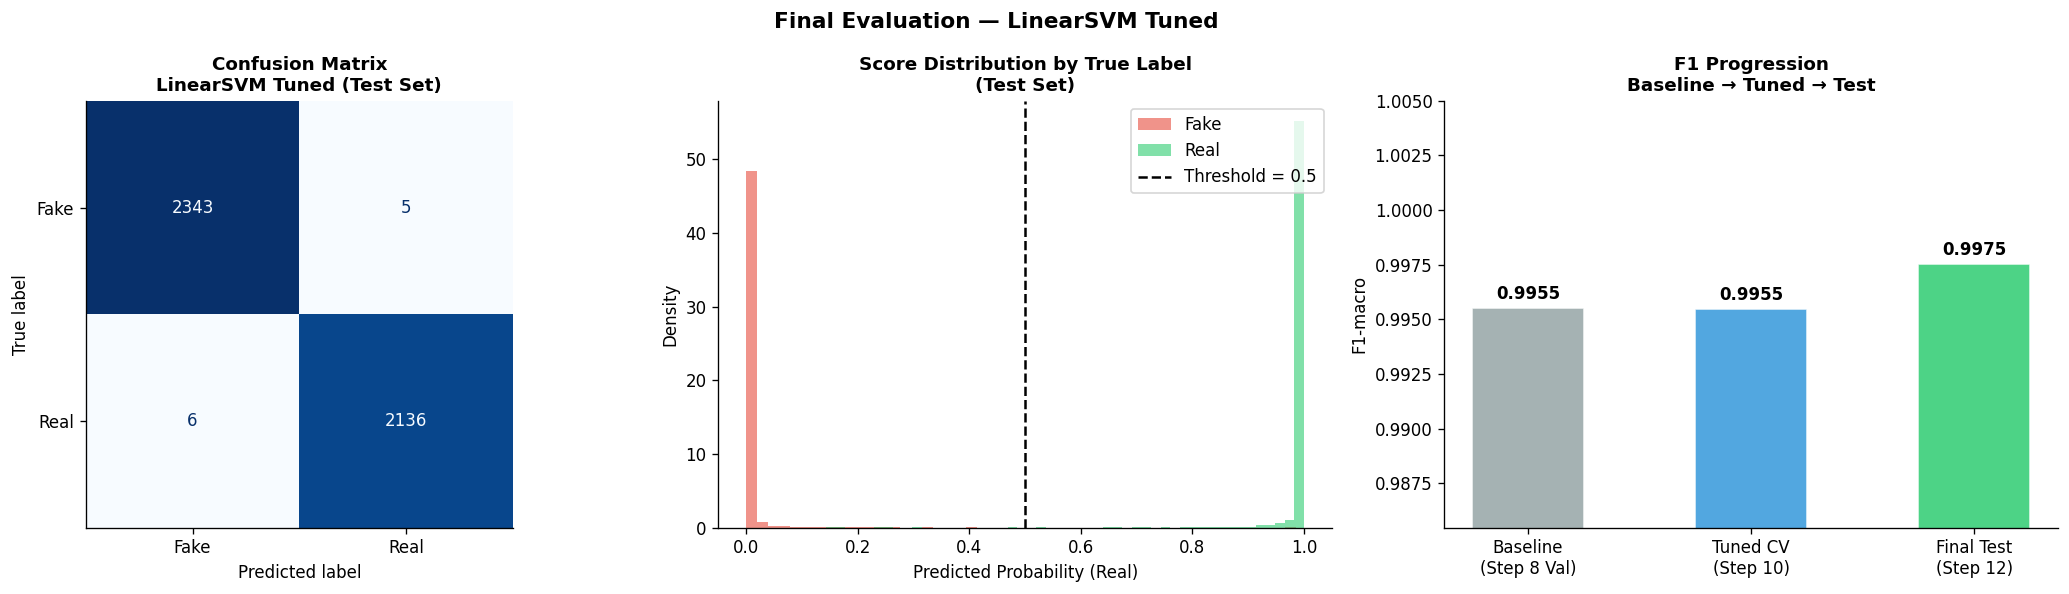

2026/05/06 15:56:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 15:58:37 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\mnnet\AppData\Local\Temp\tmp9z280org\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
Registered model 'FakeNewsClassification_LinearSVM' already exists. Creating a new version of this model...
Created version '3' of model 'FakeNewsClassification_LinearSVM'.



'FakeNewsClassification_LinearSVM' v1 → Production ✓

=== Files saved to ./models/ ===
  tfidf_vectorizer.pkl   — TF-IDF vectorizer (fit on train only)
  best_model.pkl         — Tuned LinearSVM (CalibratedClassifierCV)
  model_metadata.json    — Full run metadata

  Test F1      : 0.997545
  Test Accuracy: 0.99755
  Test ROC-AUC : 0.999904
  Leakage override applied: True


In [26]:
print(f"Tuned model   : LinearSVM (C={search.best_params_['estimator__C']})")
print(f"Ablation winner: {ablation_winner}")

# 1. Config 4 (Subject) is excluded from deployment for two reasons:
#   1. Tuned model was trained on X_tv (50k features — Title+Text only)
#      Config 4 adds 8 one-hot subject columns → 50008 features → shape mismatch
#   2. Subject column in ISOT is a known leakage risk (near-perfect label proxy)

if 'Subject' in ablation_winner or '⚠' in ablation_winner:
    print(f"\n⚠  Ablation winner '{ablation_winner}' excluded from deployment.")
    print("   Reason 1: Feature dimension mismatch — tuned model expects 50000, Config 4 has 50008.")
    print("   Reason 2: Subject column is a known leakage risk in ISOT dataset.")
    deployment_config = 'Config 3: Title + Text (baseline)'
    X_test_final      = X_test_tfidf
    print(f"   Falling back to → {deployment_config}")
elif 'Title only' in ablation_winner:
    deployment_config = ablation_winner
    X_test_final      = v_title.transform(news_df.loc[X_test.index, 'title'].fillna(''))
elif 'Text body' in ablation_winner:
    deployment_config = ablation_winner
    X_test_final      = v_body.transform(news_df.loc[X_test.index, 'clean_text'].fillna(''))
else:
    # Config 3: Title + Text — default
    deployment_config = ablation_winner
    X_test_final      = X_test_tfidf

print(f"\nDeployment config : {deployment_config}")
print(f"Test matrix shape : {X_test_final.shape}")   # must be (N, 50000)

# ── 2. Evaluate tuned model on test set ─────────────────────────────────────
# THE ONLY TIME THE TEST SET IS TOUCHED IN THE ENTIRE PIPELINE
print("\nEvaluating tuned LinearSVM on held-out test set...")
test_res  = evaluate(tuned_svm, X_test_final, y_test)
test_pred = test_res['y_pred']
test_prob = test_res['y_prob']

print(f"\n{'='*52}")
print(f"  FINAL TEST SET RESULTS — LinearSVM (Tuned)")
print(f"{'='*52}")
for k, v in test_res.items():
    if k not in ('y_pred', 'y_prob'):
        print(f"  {k:<15}: {v:.4f}")

print(f"\n  Baseline val F1 (Step 8)  : {baseline['F1 (macro)']:.4f}")
print(f"  Tuned CV F1   (Step 10)  : {search.best_score_:.4f}")
print(f"  Final test F1 (Step 12)  : {test_res['F1 (macro)']:.4f}")
print(f"  Δ tuning gain            : {search.best_score_    - baseline['F1 (macro)']:+.4f}")
print(f"  Δ test vs baseline       : {test_res['F1 (macro)'] - baseline['F1 (macro)']:+.4f}")

print('\nDetailed Classification Report:')
print(classification_report(y_test, test_pred, target_names=['Fake', 'Real']))

# ── 3. Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Confusion matrix ---
cm   = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\nLinearSVM Tuned (Test Set)',
                  fontsize=11, fontweight='bold')

# --- Probability distribution ---
for label_val, color, lbl in zip([0, 1], PALETTE, ['Fake', 'Real']):
    mask = (y_test == label_val).values
    axes[1].hist(test_prob[mask], bins=50, alpha=0.6,
                 color=color, label=lbl, density=True)
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold = 0.5')
axes[1].set_xlabel('Predicted Probability (Real)')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution by True Label\n(Test Set)',
                  fontsize=11, fontweight='bold')
axes[1].legend()

# --- F1 progression bar chart ---
stages     = ['Baseline\n(Step 8 Val)', 'Tuned CV\n(Step 10)', 'Final Test\n(Step 12)']
scores     = [baseline['F1 (macro)'], search.best_score_, test_res['F1 (macro)']]
colors_bar = ['#95a5a6', '#3498db', '#2ecc71']
bars = axes[2].bar(stages, scores, color=colors_bar, alpha=0.85,
                   width=0.5, edgecolor='white')
axes[2].bar_label(bars, fmt='%.4f', padding=3, fontsize=10, fontweight='bold')
axes[2].set_ylim(min(scores) - 0.01, 1.005)
axes[2].set_ylabel('F1-macro')
axes[2].set_title('F1 Progression\nBaseline → Tuned → Test',
                  fontsize=11, fontweight='bold')

plt.suptitle('Final Evaluation — LinearSVM Tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=120)
plt.show()

# ── 4. MLflow — log final run ────────────────────────────────────────────────
with mlflow.start_run(run_name='LinearSVM_FinalEvaluation'):
    mlflow.set_tag('stage',            'final_test_evaluation')
    mlflow.set_tag('model',            'LinearSVM_tuned')
    mlflow.set_tag('ablation_winner',   ablation_winner)
    mlflow.set_tag('deployment_config', deployment_config)

    mlflow.log_params(search.best_params_)

    mlflow.log_metrics({
        'test_accuracy'        : round(test_res['Accuracy'],    4),
        'test_f1_macro'        : round(test_res['F1 (macro)'],  4),
        'test_roc_auc'         : round(test_res['ROC-AUC'],     4),
        'test_precision'       : round(test_res['Precision'],   4),
        'test_recall'          : round(test_res['Recall'],      4),
        'baseline_val_f1'      : round(baseline['F1 (macro)'],  4),
        'tuned_cv_f1'          : round(search.best_score_,      4),
        'delta_tuning_vs_base' : round(search.best_score_     - baseline['F1 (macro)'], 4),
        'delta_test_vs_base'   : round(test_res['F1 (macro)'] - baseline['F1 (macro)'], 4),
    })

    mlflow.log_artifact('final_evaluation.png')

    mlflow.sklearn.log_model(
        tuned_svm,
        name                  = 'model',
        registered_model_name = MODEL_REGISTRY_NAME
    )

# ── 5. MLflow — promote to Production ────────────────────────────────────────
final_versions = client.get_latest_versions(MODEL_REGISTRY_NAME)
final_version  = final_versions[0].version

client.transition_model_version_stage(
    name                     = MODEL_REGISTRY_NAME,
    version                  = final_version,
    stage                    = 'Production',
    archive_existing_versions= True
)

client.set_model_version_tag(MODEL_REGISTRY_NAME, final_version,
                             'status',            'production_ready')
client.set_model_version_tag(MODEL_REGISTRY_NAME, final_version,
                             'test_f1_macro',     str(round(test_res['F1 (macro)'], 4)))
client.set_model_version_tag(MODEL_REGISTRY_NAME, final_version,
                             'deployment_config',  deployment_config)
client.set_model_version_tag(MODEL_REGISTRY_NAME, final_version,
                             'ablation_winner',    ablation_winner)

print(f"\n'{MODEL_REGISTRY_NAME}' v{final_version} → Production ✓")

# ── 6. Export for Flask deployment ───────────────────────────────────────────
os.makedirs('models', exist_ok=True)

joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(tuned_svm,        'models/best_model.pkl')

meta = {
    'deployed_model'    : 'LinearSVM',
    'best_params'       : search.best_params_,
    'ablation_winner'   : ablation_winner,
    'deployment_config' : deployment_config,
    'leakage_override'  : ablation_winner != deployment_config,
    'feature_config'    : 'TF-IDF ngram(1,2) 50k features — Title+Text',
    'baseline_val_f1'   : round(baseline['F1 (macro)'],   6),
    'tuned_cv_f1'       : round(search.best_score_,       6),
    'test_f1_macro'     : round(test_res['F1 (macro)'],   6),
    'test_accuracy'     : round(test_res['Accuracy'],     6),
    'test_roc_auc'      : round(test_res['ROC-AUC'],      6),
    'test_precision'    : round(test_res['Precision'],    6),
    'test_recall'       : round(test_res['Recall'],       6),
    'vocab_size'        : len(tfidf_vectorizer.vocabulary_),
    'ngram_range'       : '(1,2)',
    'max_features'      : 50000,
    'train_samples'     : len(X_train),
    'val_samples'       : len(X_val),
    'test_samples'      : len(X_test),
    'mlflow_model_name' : MODEL_REGISTRY_NAME,
    'mlflow_version'    : final_version,
    'mlflow_stage'      : 'Production',
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('\n=== Files saved to ./models/ ===')
print('  tfidf_vectorizer.pkl   — TF-IDF vectorizer (fit on train only)')
print('  best_model.pkl         — Tuned LinearSVM (CalibratedClassifierCV)')
print('  model_metadata.json    — Full run metadata')
print(f"\n  Test F1      : {meta['test_f1_macro']}")
print(f"  Test Accuracy: {meta['test_accuracy']}")
print(f"  Test ROC-AUC : {meta['test_roc_auc']}")
print(f"  Leakage override applied: {meta['leakage_override']}")

---
## Quick Inference Test *(Flask simulation)*

In [27]:
def predict_article(title: str, text: str) -> dict:
    combined = clean_text(title + ' ' + text)
    vec      = tfidf_vectorizer.transform([combined])

    pred = tuned_svm.predict(vec)[0]

    if not hasattr(tuned_svm, 'predict_proba'):
        raise ValueError("Deployed model must support predict_proba for confidence scores.")
    prob = tuned_svm.predict_proba(vec)[0]

    return {
        'label'     : 'REAL' if pred == 1 else 'FAKE',
        'confidence': round(float(max(prob)) * 100, 2),
        'fake_prob' : round(float(prob[0]) * 100, 2),
        'real_prob' : round(float(prob[1]) * 100, 2),
    }

sample_real = news_df[news_df['label'] == 1].iloc[10]
sample_fake = news_df[news_df['label'] == 0].iloc[10]

r1 = predict_article(sample_real['title'], sample_real['text'])
r2 = predict_article(sample_fake['title'], sample_fake['text'])

print('=== Inference Test ===')
print(f'\nActual: REAL  | Predicted: {r1["label"]:<4} | Confidence: {r1["confidence"]}%')
print(f'Title : {sample_real["title"][:90]}')
print(f'\nActual: FAKE  | Predicted: {r2["label"]:<4} | Confidence: {r2["confidence"]}%')
print(f'Title : {sample_fake["title"][:90]}')

=== Inference Test ===

Actual: REAL  | Predicted: REAL | Confidence: 100.0%
Title : Obama to call for increases in budget for SEC, CFTC: White House

Actual: FAKE  | Predicted: FAKE | Confidence: 100.0%
Title : FATHER OF BENGHAZI VICTIM TY WOODS SPEAKS UP AGAINST HILLARY: “My son would still be alive
